# \(A_h\) quadrature resolution study

Measure how coarse `a_h_resolution` can be before the space-integrated kernel \(A_h\)
(and Gutenberg–Richter thinning forecasts) change by more than a stated tolerance.

**Not MAGNET / FINE.** MAGNET magnitude noise would swamp quadrature error.
`magnitude_generator` is `simulate_magnitudes` only.

| Piece | Value |
|-------|--------|
| Cost | `etas/rate_simulation.py`: `A_h`, `lambda_s_total`, `simulate_catalog_continuation_thinning` |
| Default | `a_h_resolution=500`, `a_h_stretch=3.5` (parent-centered stretched grid) |
| Reference | `resolution=1500`, same polygon / θ / stretch |
| Config knob | `a_h_resolution` in `config/rolling_continuation_*.json` |

Cache `_A_H_CACHE` is per `(polygon, parent mag/loc, ETAS params, resolution, stretch)`.
Every **new** forecast event is a new parent, so the cache does not save the thinning loop.

Pytest lock-in (tiny polygon, not this notebook): `tests/test_ah_resolution.py`.


In [1]:
%matplotlib inline
from __future__ import annotations

import json
import sys
import time
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import Markdown, display
from shapely.geometry import Point, Polygon

REPO = Path.cwd().resolve()
if not (REPO / "etas" / "rate_simulation.py").is_file():
    if REPO.name == "notebooks":
        REPO = REPO.parent
    else:
        for parent in REPO.parents:
            if (parent / "etas" / "rate_simulation.py").is_file():
                REPO = parent
                break
if str(REPO) not in sys.path:
    sys.path.insert(0, str(REPO))

import etas.mc_b_est as mc_b_est
import etas.rate_simulation as rate_simulation
import etas.utility_functions as utility_functions

plt.rcParams["figure.dpi"] = 110


def show_fig(fig=None):
    if fig is None:
        fig = plt.gcf()
    display(fig)
    plt.close(fig)



## Knobs

Polygon and θ match Hauksson rolling continuation (`mc = 2.4`).
Phase 3 uses a short window and `max_forecast_events` so the cell stays interactive.
Set `FORCE_RECOMPUTE = False` to reload `outputs/ah_resolution_study.json`.


In [2]:
POLYGON_NPY = REPO / "input_data" / "hauksson_polygon_from_notebook.npy"
CACHE_PATH = REPO / "outputs" / "ah_resolution_study.json"
FORCE_RECOMPUTE = False

THETA_0 = {
    "log10_mu": -5.8,
    "log10_k0": -2.6,
    "a": 1.8,
    "log10_c": -2.5,
    "omega": -0.02,
    "log10_tau": 3.5,
    "log10_d": -0.85,
    "gamma": 1.3,
    "rho": 0.66,
}
MC = 2.4
BETA = float(np.log(10.0))
STRETCH = 3.5
REFERENCE_RESOLUTION = 1500
RESOLUTIONS = (50, 100, 200, 300, 500, 800, 1000)
AH_TOL = 0.005
SEED = 1905

PHASE3_DAYS = 2.0
PHASE3_MAX_EVENTS = 40
PHASE3_AUX_END = pd.Timestamp("2016-05-23")
RUN_PHASE3 = True

PARAMS = utility_functions.expand_theta_log10(dict(THETA_0))
PARAMS["m_c"] = float(MC)


def kernel_width_c(m: float) -> float:
    return float(PARAMS["d"] * np.exp(PARAMS["gamma"] * (m - PARAMS["m_c"])))



## Polygon and parent placements (interior / near edge / slightly outside)


polygon bounds (lat, lon) (29.98162473395039, -123.06256700323657, 39.31006291164599, -113.74762208056184)
mags (2.4, 3.4, 4.0, 5.0, 6.0, 7.0)
  interior   lon=-117.9573 lat=35.0100 inside=True
  near_edge  lon=-115.3830 lat=30.5144 inside=True
  outside    lon=-115.0911 lat=30.0046 inside=False


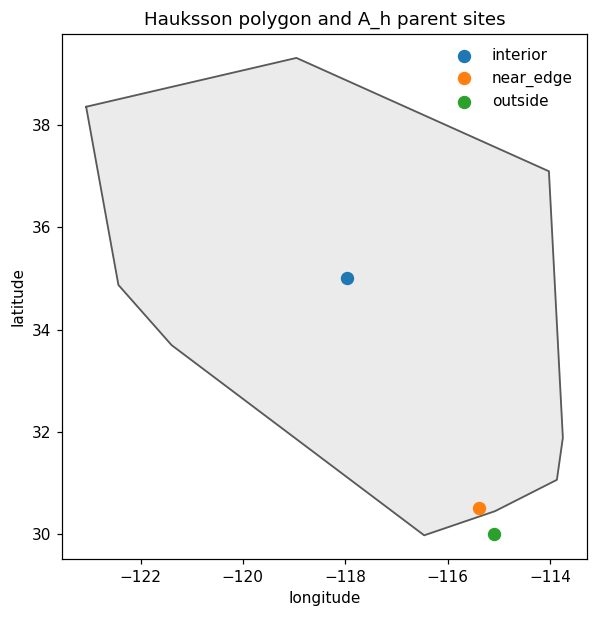

In [3]:
coords = np.load(POLYGON_NPY)
POLY = Polygon(coords)
assert POLY.is_valid and not POLY.is_empty, POLY


def parent_placements(poly: Polygon) -> dict[str, dict[str, float]]:
    centroid = poly.centroid
    boundary = poly.exterior.interpolate(0.42, normalized=True)
    dlat = float(boundary.x - centroid.x)
    dlon = float(boundary.y - centroid.y)

    def lon_lat(frac: float, extra: float = 0.0) -> tuple[float, float]:
        lat = float(centroid.x + frac * dlat + extra * dlat)
        lon = float(centroid.y + frac * dlon + extra * dlon)
        return lon, lat

    lon_i, lat_i = lon_lat(0.0)
    lon_e, lat_e = lon_lat(0.97)
    if not poly.contains(Point(lat_e, lon_e)):
        lon_e, lat_e = lon_lat(0.90)
    lon_o, lat_o = lon_lat(1.0, extra=0.08)
    out = {
        "interior": {"lon": lon_i, "lat": lat_i},
        "near_edge": {"lon": lon_e, "lat": lat_e},
        "outside": {"lon": lon_o, "lat": lat_o},
    }
    assert poly.contains(Point(lat_i, lon_i))
    assert poly.contains(Point(lat_e, lon_e))
    assert not poly.contains(Point(lat_o, lon_o))
    return out


PLACEMENTS = parent_placements(POLY)
MAGS = tuple(sorted({float(MC), float(MC) + 1.0, 4.0, 5.0, 6.0, 7.0}))
ALL_RESOLUTIONS = tuple(RESOLUTIONS) + (int(REFERENCE_RESOLUTION),)

print("polygon bounds (lat, lon)", POLY.bounds)
print("mags", MAGS)
for name, xy in PLACEMENTS.items():
    inside = POLY.contains(Point(xy["lat"], xy["lon"]))
    print(f"  {name:10s} lon={xy['lon']:.4f} lat={xy['lat']:.4f} inside={inside}")

fig, ax = plt.subplots(figsize=(6.2, 6.2))
px, py = zip(*POLY.exterior.coords)
ax.plot(py, px, color="0.35", lw=1.2)
ax.fill(py, px, color="0.92", zorder=0)
for name, xy in PLACEMENTS.items():
    ax.scatter(xy["lon"], xy["lat"], s=60, zorder=3, label=name)
ax.set_xlabel("longitude")
ax.set_ylabel("latitude")
ax.set_title("Hauksson polygon and A_h parent sites")
ax.set_aspect("equal", adjustable="box")
ax.legend(frameon=False)
show_fig(fig)



## Phase 1 — kernel-only \(A_h\) vs resolution 1500

Relative error \(|A_h(\mathrm{res})-A_h(1500)| / A_h(1500)\).
Sensitivity should grow toward the edge / outside and at small \(C = d\,e^{\gamma(m-m_c)}\).


loaded Phase 1 from cache: 18 rows


,placement,m,C,A_h_ref,relerr_50,relerr_100,relerr_200,relerr_300,relerr_500,relerr_800,relerr_1000
0,interior,2.4,0.141254,0.043518,0.251298,0.058214,0.014030,0.006060,0.002012,0.000632,0.000314
1,interior,3.4,0.518302,0.111606,0.169890,0.039943,0.009666,0.004178,0.001388,0.000436,0.000216
2,interior,4.0,1.130661,0.196367,0.134545,0.031892,0.007732,0.003343,0.001111,0.000349,0.000173
3,interior,5.0,4.148732,0.503421,0.091733,0.021943,0.005332,0.002306,0.000766,0.000241,0.000120
4,interior,6.0,15.222927,1.289721,0.062809,0.015120,0.003680,0.001591,0.000529,0.000166,0.000082
5,interior,7.0,55.857437,3.298712,0.043178,0.010438,0.002545,0.001098,0.000365,0.000114,0.000057
6,near_edge,2.4,0.141254,0.043440,0.350522,0.078608,0.018860,0.008133,0.002702,0.000848,0.000422
7,near_edge,3.4,0.518302,0.111116,0.231128,0.053971,0.013015,0.005608,0.001869,0.000587,0.000294
8,near_edge,4.0,1.130661,0.194917,0.183691,0.043177,0.010431,0.004485,0.001501,0.000472,0.000238
9,near_edge,5.0,4.148732,0.494649,0.126227,0.029944,0.007239,0.003075,0.001047,0.000330,0.000172


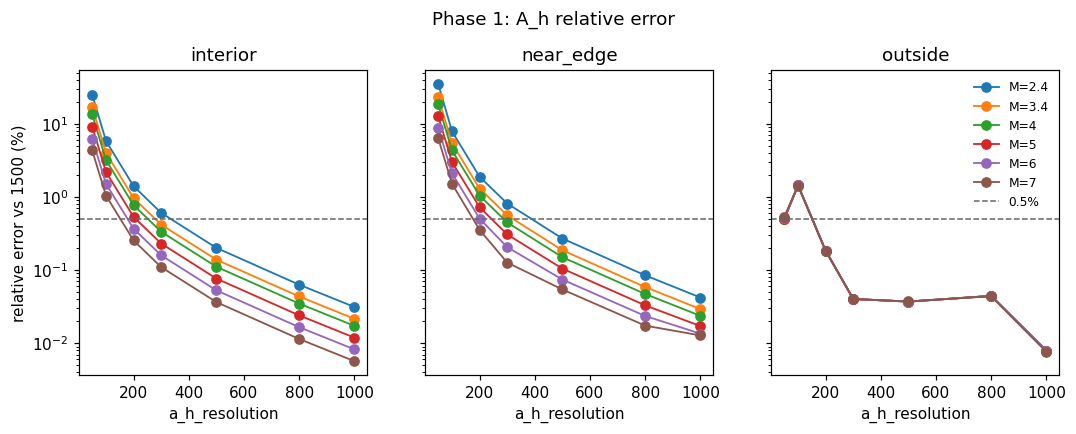

In [4]:
def make_parent(m: float, lon: float, lat: float, t: float = 0.0) -> dict:
    return {"m": float(m), "x": float(lon), "y": float(lat), "t": float(t)}


def rel_err(value: float, ref: float) -> float:
    ref_abs = abs(float(ref))
    if ref_abs < 1e-30:
        return float("nan")
    return abs(float(value) - float(ref)) / ref_abs


def load_cache() -> dict:
    if FORCE_RECOMPUTE or not CACHE_PATH.is_file():
        return {}
    return json.loads(CACHE_PATH.read_text())


def save_cache(payload: dict) -> None:
    CACHE_PATH.parent.mkdir(parents=True, exist_ok=True)
    CACHE_PATH.write_text(json.dumps(payload, indent=2))
    print("wrote", CACHE_PATH)


CACHE = load_cache()

if "phase1" in CACHE:
    phase1 = pd.DataFrame(CACHE["phase1"])
    print("loaded Phase 1 from cache:", len(phase1), "rows")
else:
    rows = []
    t0 = time.perf_counter()
    n_done = 0
    n_total = len(PLACEMENTS) * len(MAGS)
    for place, xy in PLACEMENTS.items():
        for mag in MAGS:
            parent = make_parent(mag, xy["lon"], xy["lat"])
            ref = rate_simulation.A_h(
                POLY, parent, PARAMS, resolution=REFERENCE_RESOLUTION, stretch=STRETCH
            )
            row = {
                "placement": place,
                "m": mag,
                "C": kernel_width_c(mag),
                "A_h_ref": ref,
            }
            for res in RESOLUTIONS:
                val = rate_simulation.A_h(
                    POLY, parent, PARAMS, resolution=int(res), stretch=STRETCH
                )
                row[f"A_h_{res}"] = val
                row[f"relerr_{res}"] = rel_err(val, ref)
            rows.append(row)
            n_done += 1
            print(f"Phase 1 {n_done}/{n_total} {place} M={mag:.1f}  A_h(1500)={ref:.4e}")
    phase1 = pd.DataFrame(rows)
    CACHE["phase1"] = phase1.to_dict(orient="records")
    CACHE["meta"] = {
        "polygon": str(POLYGON_NPY.relative_to(REPO)),
        "mc": MC,
        "stretch": STRETCH,
        "reference_resolution": REFERENCE_RESOLUTION,
        "resolutions": list(RESOLUTIONS),
        "theta_0": THETA_0,
        "phase1_seconds": time.perf_counter() - t0,
    }
    save_cache(CACHE)

err_cols = [f"relerr_{res}" for res in RESOLUTIONS]
display(phase1[["placement", "m", "C", "A_h_ref", *err_cols]].round(6))

fig, axes = plt.subplots(1, 3, figsize=(11.5, 3.6), sharey=True)
for ax, place in zip(axes, PLACEMENTS):
    sub = phase1[phase1["placement"] == place]
    for _, row in sub.iterrows():
        ax.plot(
            list(RESOLUTIONS),
            [row[f"relerr_{res}"] * 100 for res in RESOLUTIONS],
            marker="o",
            lw=1.2,
            label=f"M={row['m']:g}",
        )
    ax.axhline(AH_TOL * 100, color="0.4", ls="--", lw=1, label=f"{AH_TOL*100:g}%")
    ax.set_title(place)
    ax.set_xlabel("a_h_resolution")
    ax.set_yscale("log")
axes[0].set_ylabel("relative error vs 1500 (%)")
axes[-1].legend(frameon=False, fontsize=8, loc="upper right")
fig.suptitle("Phase 1: A_h relative error", y=1.03)
show_fig(fig)



## Phase 2 — \(\lambda_s^{\mathrm{tot}}\) at a few times

Same polygon / θ. History is a handful of Phase-1 parents with assigned times:
just after the large event, mid-window, and near \(t_{\mathrm{end}}\).


loaded Phase 2 from cache: 3 rows


,time_label,t,lambda_ref,relerr_50,relerr_100,relerr_200,relerr_300,relerr_500,relerr_800,relerr_1000
0,just_after_large,1000.0001,904.614715,0.043309,0.010468,0.002552,0.001101,0.000366,0.000115,0.000057
1,mid_window,1003.5000,2.046977,0.029095,0.006992,0.001700,0.000731,0.000245,0.000077,0.000039
2,near_t_end,1006.9990,1.506137,0.020394,0.004899,0.001191,0.000512,0.000171,0.000054,0.000027


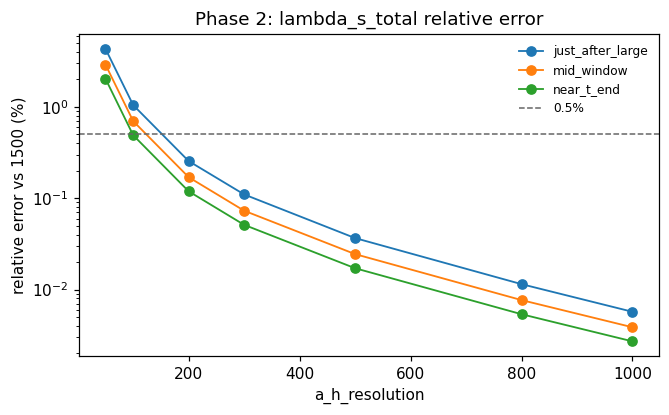

In [5]:
T_LARGE = 1000.0
T_END = T_LARGE + 7.0
PHASE2_TIMES = {
    "just_after_large": T_LARGE + 1e-4,
    "mid_window": 0.5 * (T_LARGE + T_END),
    "near_t_end": T_END - 1e-3,
}
PHASE2_HISTORY = [
    make_parent(7.0, **{k: PLACEMENTS["interior"][k] for k in ("lon", "lat")}, t=T_LARGE),
    make_parent(5.0, **{k: PLACEMENTS["near_edge"][k] for k in ("lon", "lat")}, t=T_LARGE - 0.25),
    make_parent(4.0, **{k: PLACEMENTS["outside"][k] for k in ("lon", "lat")}, t=T_LARGE - 2.0),
    make_parent(MC, **{k: PLACEMENTS["interior"][k] for k in ("lon", "lat")}, t=T_LARGE - 10.0),
]


if "phase2" in CACHE:
    phase2 = pd.DataFrame(CACHE["phase2"])
    print("loaded Phase 2 from cache:", len(phase2), "rows")
else:
    rows = []
    t0 = time.perf_counter()
    for label, t_eval in PHASE2_TIMES.items():
        ref = rate_simulation.lambda_s_total(
            t_eval, PHASE2_HISTORY, POLY, PARAMS, REFERENCE_RESOLUTION, STRETCH
        )
        row = {"time_label": label, "t": t_eval, "lambda_ref": ref}
        for res in RESOLUTIONS:
            val = rate_simulation.lambda_s_total(
                t_eval, PHASE2_HISTORY, POLY, PARAMS, int(res), STRETCH
            )
            row[f"lambda_{res}"] = val
            row[f"relerr_{res}"] = rel_err(val, ref)
        rows.append(row)
        print(f"Phase 2 {label}: lambda(1500)={ref:.4e}")
    phase2 = pd.DataFrame(rows)
    CACHE["phase2"] = phase2.to_dict(orient="records")
    CACHE.setdefault("meta", {})["phase2_seconds"] = time.perf_counter() - t0
    save_cache(CACHE)

display(phase2[["time_label", "t", "lambda_ref", *err_cols]].round(8))

fig, ax = plt.subplots(figsize=(6.8, 3.8))
for _, row in phase2.iterrows():
    ax.plot(
        list(RESOLUTIONS),
        [row[f"relerr_{res}"] * 100 for res in RESOLUTIONS],
        marker="o",
        lw=1.2,
        label=row["time_label"],
    )
ax.axhline(AH_TOL * 100, color="0.4", ls="--", lw=1, label=f"{AH_TOL*100:g}%")
ax.set_xlabel("a_h_resolution")
ax.set_ylabel("relative error vs 1500 (%)")
ax.set_yscale("log")
ax.set_title("Phase 2: lambda_s_total relative error")
ax.legend(frameon=False, fontsize=8)
show_fig(fig)



## Phase 3 — same-seed GR thinning (not MAGNET)

`np.random.seed(SEED)` before each run. Compare catalog count and max magnitude
against resolution 1500. If 1500 is too slow, the cell records that and compares to 500.


thinning:  48%|████▊     | 19/40 [00:00<00:00, 37.95event/s, last=2016-05-24 11:34:36, end=2016-05-25 00:00:00, left=12.42h]


Phase 3 res=  50  n= 19  max_mag=4.369604834725016  0.51s


thinning:  25%|██▌       | 10/40 [00:00<00:00, 384.23event/s, last=2016-05-24 16:59:50, end=2016-05-25 00:00:00, left=7.00h]


Phase 3 res= 100  n= 10  max_mag=3.5251594521172676  0.03s


thinning:  22%|██▎       | 9/40 [00:00<00:00, 220.35event/s, last=2016-05-24 18:42:28, end=2016-05-25 00:00:00, left=5.29h]


...

Phase 3 res=1000  n=  9  max_mag=3.4718007029883937  10.71s


thinning:  22%|██▎       | 9/40 [00:30<01:46,  3.43s/event, last=2016-05-24 19:27:46, end=2016-05-25 00:00:00, left=4.54h]

Phase 3 res=1500  n=  9  max_mag=3.4718007029883937  30.88s
wrote /home/neriberman/Repos/etas/outputs/ah_resolution_study.json


,resolution,seconds,n,max_mag,min_time,max_time,dn,dmax_mag
0,50,0.509878,19,4.369605,2016-05-23 00:01:29.128879364,2016-05-24 11:34:36.605304246,10,0.897804
1,100,0.031020,10,3.525159,2016-05-23 00:01:33.305411352,2016-05-24 16:59:50.119806491,1,0.053359
2,200,0.045914,9,3.471801,2016-05-23 00:01:34.366107673,2016-05-24 18:42:28.988143706,0,0.000000
3,300,0.123389,9,3.471801,2016-05-23 00:01:34.562431223,2016-05-24 19:08:05.029589909,0,0.000000
4,500,0.345124,9,3.471801,2016-05-23 00:01:34.662557038,2016-05-24 19:21:12.518221740,0,0.000000
5,800,5.701769,9,3.471801,2016-05-23 00:01:34.696825930,2016-05-24 19:25:42.418949877,0,0.000000
6,1000,10.709167,9,3.471801,2016-05-23 00:01:34.704709109,2016-05-24 19:26:44.621925760,0,0.000000
7,1500,30.876115,9,3.471801,2016-05-23 00:01:34.712501136,2016-05-24 19:27:46.056477375,0,0.000000


Phase 3 reference resolution **1500**: n=9, max mag=3.4718007029883937.

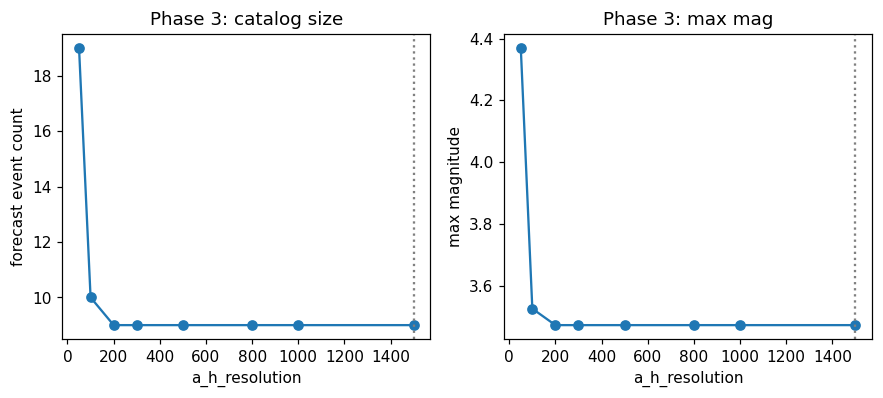

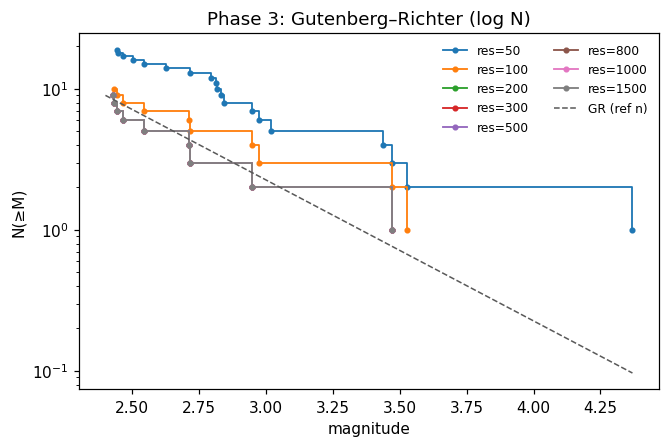

In [8]:
def thinning_summary(catalog: pd.DataFrame) -> dict:
    if catalog is None or len(catalog) == 0:
        return {
            "n": 0,
            "max_mag": None,
            "min_time": None,
            "max_time": None,
            "magnitudes": [],
        }
    mags = [float(x) for x in catalog["magnitude"]]
    return {
        "n": int(len(catalog)),
        "max_mag": float(max(mags)),
        "min_time": str(pd.Timestamp(catalog["time"].min())),
        "max_time": str(pd.Timestamp(catalog["time"].max())),
        "magnitudes": mags,
    }


def run_thinning(resolution: int) -> tuple[pd.DataFrame, float]:
    aux_end = PHASE3_AUX_END
    sim_end = aux_end + pd.Timedelta(days=PHASE3_DAYS)
    interior = PLACEMENTS["interior"]
    aux = pd.DataFrame(
        {
            "latitude": [interior["lat"]],
            "longitude": [interior["lon"]],
            "time": [aux_end],
            "magnitude": [6.0],
        }
    )
    np.random.seed(SEED)
    t0 = time.perf_counter()
    catalog = rate_simulation.simulate_catalog_continuation_thinning(
        aux,
        aux_end,
        sim_end,
        POLY,
        THETA_0,
        MC,
        beta_main=BETA,
        magnitude_generator=mc_b_est.simulate_magnitudes,
        a_h_resolution=int(resolution),
        a_h_stretch=STRETCH,
        max_forecast_events=PHASE3_MAX_EVENTS,
    )
    return catalog, time.perf_counter() - t0


def phase3_cache_has_magnitudes(payload: dict) -> bool:
    rows = payload.get("phase3") or []
    return bool(rows) and all(isinstance(r.get("magnitudes"), list) for r in rows)


if not RUN_PHASE3:
    phase3 = pd.DataFrame()
    print("RUN_PHASE3 is False; skip")
elif phase3_cache_has_magnitudes(CACHE):
    phase3 = pd.DataFrame(CACHE["phase3"])
    print("loaded Phase 3 from cache:", len(phase3), "rows")
else:
    rows = []
    for res in ALL_RESOLUTIONS:
        cat, elapsed = run_thinning(res)
        row = {"resolution": int(res), "seconds": elapsed, **thinning_summary(cat)}
        rows.append(row)
        print(
            f"Phase 3 res={res:4d}  n={row['n']:3d}  "
            f"max_mag={row['max_mag']}  {elapsed:.2f}s"
        )
    phase3 = pd.DataFrame(rows)
    CACHE["phase3"] = phase3.to_dict(orient="records")
    save_cache(CACHE)

if len(phase3):
    ref_rows = phase3[phase3["resolution"] == REFERENCE_RESOLUTION]
    used_ref = int(REFERENCE_RESOLUTION)
    if len(ref_rows) == 0:
        used_ref = 500
        ref_rows = phase3[phase3["resolution"] == 500]
        print(
            f"No resolution={REFERENCE_RESOLUTION} catalog; "
            f"comparing Phase 3 against {used_ref}"
        )
    ref = ref_rows.iloc[0]
    phase3 = phase3.copy()
    phase3["dn"] = phase3["n"] - int(ref["n"])
    phase3["dmax_mag"] = [
        None if (pd.isna(a) or pd.isna(ref["max_mag"])) else float(a) - float(ref["max_mag"])
        for a in phase3["max_mag"]
    ]
    display(phase3.drop(columns=["magnitudes"], errors="ignore"))
    display(
        Markdown(
            f"Phase 3 reference resolution **{used_ref}**: "
            f"n={int(ref['n'])}, max mag={ref['max_mag']}."
        )
    )
    fig, axes = plt.subplots(1, 2, figsize=(9.5, 3.6))
    axes[0].plot(phase3["resolution"], phase3["n"], marker="o")
    axes[0].axvline(used_ref, color="0.5", ls=":")
    axes[0].set_xlabel("a_h_resolution")
    axes[0].set_ylabel("forecast event count")
    axes[0].set_title("Phase 3: catalog size")
    axes[1].plot(phase3["resolution"], phase3["max_mag"], marker="o")
    axes[1].axvline(used_ref, color="0.5", ls=":")
    axes[1].set_xlabel("a_h_resolution")
    axes[1].set_ylabel("max magnitude")
    axes[1].set_title("Phase 3: max mag")
    show_fig(fig)

    fig, ax = plt.subplots(figsize=(6.8, 4.2))
    for _, row in phase3.iterrows():
        mags = np.sort(np.asarray(row.get("magnitudes") or [], dtype=float))
        if mags.size == 0:
            continue
        n_ge = np.arange(mags.size, 0, -1, dtype=float)
        ax.step(
            mags,
            n_ge,
            where="post",
            marker="o",
            ms=3,
            lw=1.2,
            label=f"res={int(row['resolution'])}",
        )
    m_hi = float(np.nanmax(phase3["max_mag"].to_numpy(dtype=float)))
    m_line = np.linspace(MC, m_hi, 80)
    n0 = float(ref["n"])
    ax.plot(
        m_line,
        n0 * np.exp(-BETA * (m_line - MC)),
        color="0.35",
        ls="--",
        lw=1,
        label="GR (ref n)",
    )
    ax.set_xlabel("magnitude")
    ax.set_ylabel("N(≥M)")
    ax.set_yscale("log")
    ax.set_title("Phase 3: Gutenberg–Richter (log N)")
    ax.legend(frameon=False, fontsize=8, ncol=2)
    show_fig(fig)



## Recommendation

Coarsest resolution whose Phase-1 error stays under `AH_TOL` (default 0.5%),
split by placement and by \(M\le 6\) vs \(M=7\). Adaptive rule uses kernel width \(C\).


In [9]:
def coarsest_ok(frame: pd.DataFrame, mag_max: float | None = None) -> int | None:
    sub = frame if mag_max is None else frame[frame["m"] <= mag_max]
    if sub.empty:
        return None
    for res in RESOLUTIONS:
        if float(sub[f"relerr_{res}"].max()) <= AH_TOL:
            return int(res)
    return int(REFERENCE_RESOLUTION)


lines = [
    "### Production default",
    "",
    f"Tolerance on $A_h$: **{AH_TOL*100:g}%** relative to resolution {REFERENCE_RESOLUTION}.",
    "",
]
for place in PLACEMENTS:
    sub = phase1[phase1["placement"] == place]
    r_all = coarsest_ok(sub)
    r_le6 = coarsest_ok(sub, mag_max=6.0)
    r_m7 = coarsest_ok(sub[sub["m"] == 7.0])
    lines.append(
        f"- **{place}**: coarsest with err≤{AH_TOL*100:g}% for all M is `{r_all}`; "
        f"for M≤6 is `{r_le6}`; for M=7 is `{r_m7}`."
    )

interior_le6 = coarsest_ok(phase1[phase1["placement"] == "interior"], mag_max=6.0)
edge_all = coarsest_ok(phase1[phase1["placement"] != "interior"])
global_all = coarsest_ok(phase1)

lines += [
    "",
    f"- Interior M≤6: **{interior_le6}**",
    f"- Edge + outside (all M): **{edge_all}**",
    f"- Conservative (all placements, all M): **{global_all}**",
    "",
    "Suggested rule:",
    "",
]
if interior_le6 is not None and edge_all is not None and interior_le6 < edge_all:
    lines += [
        f"- Use **`a_h_resolution = {interior_le6}`** when the parent is interior "
        "and the kernel is wide (large $C$, typically M≳5).",
        f"- Use **`a_h_resolution = {edge_all}`** near the polygon edge, outside, "
        "or at small $C$ (M near $m_c$).",
        f"- Safe production default if you do not want an adaptive switch: **{global_all}**.",
    ]
else:
    lines += [
        f"- Use a single production default **`a_h_resolution = {global_all}`** "
        f"(meets {AH_TOL*100:g}% on every placement and magnitude in this sweep).",
    ]

if len(phase3):
    match = phase3[phase3["dn"] == 0]
    if len(match):
        coarsest_match = int(match["resolution"].min())
        lines += [
            "",
            "Phase 3 (one seed, GR magnitudes, 2-day window, M6 interior parent): "
            f"catalog count matches the reference from resolution **{coarsest_match}** upward "
            "in this sweep.",
        ]

per_m_rows = []
for mag in MAGS:
    sub = phase1[phase1["m"] == mag]
    per_m_rows.append(
        {
            "m": mag,
            "C": kernel_width_c(mag),
            "coarsest_all_placements": coarsest_ok(sub),
            "coarsest_interior": coarsest_ok(sub[sub["placement"] == "interior"]),
            "coarsest_near_edge": coarsest_ok(sub[sub["placement"] == "near_edge"]),
        }
    )
per_m = pd.DataFrame(per_m_rows)
lines += [
    "",
    "Per-magnitude coarsest grid (all placements must be ≤ tolerance):",
    "",
]
for _, row in per_m.iterrows():
    lines.append(
        f"- M={row['m']:g} (C={row['C']:.3g}): **{int(row['coarsest_all_placements'])}** "
        f"(interior {int(row['coarsest_interior'])}, "
        f"near-edge {int(row['coarsest_near_edge'])})"
    )

switch_500 = per_m[per_m["coarsest_all_placements"] == 500]["m"].max()
switch_300 = per_m[per_m["coarsest_all_placements"] <= 300]["m"].min()
switch_200 = per_m[per_m["coarsest_all_placements"] <= 200]["m"].min()
lines += [
    "",
    "Mag / kernel-width switch implied by this sweep:",
    "",
    f"- Keep **500** for M≤{switch_500:g} (peaky kernel, small C, including near-edge).",
]
if pd.notna(switch_300):
    lines.append(
        f"- **300** is enough from M≥{switch_300:g} across interior and edge."
    )
if pd.notna(switch_200):
    lines.append(
        f"- **200** is enough from M≥{switch_200:g} (large C, smooth kernel)."
    )
lines += [
    "",
    "If you do not want a mag-adaptive rule, leave production at **500**.",
]

display(Markdown("\n".join(lines)))

summary = phase1.groupby("placement")[err_cols].max()
summary.columns = [c.replace("relerr_", "max_relerr_") for c in summary.columns]
display(Markdown("Max Phase-1 relative error by placement:"))
display(summary.round(6))
display(Markdown("Coarsest resolution by magnitude:"))
display(per_m.round(4))



### Production default

Tolerance on $A_h$: **0.5%** relative to resolution 1500.

- **interior**: coarsest with err≤0.5% for all M is `500`; for M≤6 is `500`; for M=7 is `200`.
- **near_edge**: coarsest with err≤0.5% for all M is `500`; for M≤6 is `500`; for M=7 is `200`.
- **outside**: coarsest with err≤0.5% for all M is `200`; for M≤6 is `200`; for M=7 is `200`.

- Interior M≤6: **500**
- Edge + outside (all M): **500**
- Conservative (all placements, all M): **500**

Suggested rule:

- Use a single production default **`a_h_resolution = 500`** (meets 0.5% on every placement and magnitude in this sweep).

Phase 3 (one seed, GR magnitudes, 2-day window, M6 interior parent): catalog count matches the reference from resolution **200** upward in this sweep.

Per-magnitude coarsest grid (all placements must be ≤ tolerance):

- M=2.4 (C=0.141): **500** (interior 500, near-edge 500)
- M=3.4 (C=0.518): **500** (interior 300, near-edge 500)
- M=4 (C=1.13): **300** (interior 300, near-edge 300)
- M=5 (C=4.15): **300** (interior 300, near-edge 300)
- M=6 (C=15.2): **300** (interior 200, near-edge 300)
- M=7 (C=55.9): **200** (interior 200, near-edge 200)

Mag / kernel-width switch implied by this sweep:

- Keep **500** for M≤3.4 (peaky kernel, small C, including near-edge).
- **300** is enough from M≥4 across interior and edge.
- **200** is enough from M≥7 (large C, smooth kernel).

If you do not want a mag-adaptive rule, leave production at **500**.

Max Phase-1 relative error by placement:

,max_relerr_50,max_relerr_100,max_relerr_200,max_relerr_300,max_relerr_500,max_relerr_800,max_relerr_1000
placement,,,,,,,
interior,0.251298,0.058214,0.014030,0.006060,0.002012,0.000632,0.000314
near_edge,0.350522,0.078608,0.018860,0.008133,0.002702,0.000848,0.000422
outside,0.005354,0.014462,0.001847,0.000403,0.000373,0.000444,0.000080


Coarsest resolution by magnitude:

,m,C,coarsest_all_placements,coarsest_interior,coarsest_near_edge
0,2.4,0.1413,500,500,500
1,3.4,0.5183,500,300,500
2,4.0,1.1307,300,300,300
3,5.0,4.1487,300,300,300
4,6.0,15.2229,300,200,300
5,7.0,55.8574,200,200,200
